In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import AutoMD.system import System
import scipy.integrate as intg
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'


SyntaxError: invalid syntax (4060971312.py, line 5)

In [ ]:
# load systems - change so this is done with json files later maybe? easier to jsut have the data in one place then
#li_tfsi_fsi = System(
#    sysdir="/home/felix/analyses/analysis_cleaned/li_tfsi_fsi",
#    system_name="li_tfsi_fsi",
#    cations=[("Li", 1, 1)],
#    anions=[("TFSI-", -1, 15), ("FSI-", -1, 9)],
#    n_molecules=200,
#    ff_file_name="data.lmp", # Replace with whatever your fftool output is named
#    input_file_name="in_append_tmp.lmp"
#)

li_tfsi_pf6 = System(
    sysdir="/home/felix/analyses/analysis_cleaned/li.xyz_200__tfsi.zmat_100__pf6.zmat_100",
    system_name="li_tfsi_pf6",
    cations=[("Li", 1, 1)],
    anions=[("TFSI-", -1, 15), ("PF6-", -1, 7)],
    n_molecules=200,
    ff_file_name="data.lmp", # Replace with whatever your fftool output is named
    input_file_name="in_append_tmp.lmp"
)

li_k_tfsi_fsi_pf6 = System(
    sysdir="/home/felix/analyses/analysis_cleaned/li.xyz_150__k.xyz_150__tfsi.zmat_100__fsi.zmat_100__pf6.zmat_100",
    system_name="li_tfsi_pf6",
    cations=[("Li", 1, 1), ("K", 1, 1)],
    anions=[("TFSI-", -1, 15), ("FSI-", -1, 7), ("PF6-", -1, 7)],
    n_molecules=200,
    ff_file_name="data.lmp", # Replace with whatever your fftool output is named
    input_file_name="in_append_tmp.lmp"
)


Dump interval: 1000
Assigned MDAnalysis residues: {'Li': 200, 'TFSI': 100, 'PF6': 100}


/home/felix/anaconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [ ]:
# 1. Grab your system from the list
# put in list - unnecessary? Might be nice for loops
system_list = [li_tfsi_pf6, li_k_tfsi_fsi_pf6]

# build dataframe
systems = pd.DataFrame({s.system_name: s.to_dict() for s in system_list})

my_system = system_list[0]

In [ ]:
import scipy.constants as const

# extract system properties
volume_A3 = my_system.universe.trajectory.ts.volume
n_atoms = len(my_system.universe.atoms)
number_density = n_atoms / volume_A3
total_mass_g_mol = my_system.universe.atoms.total_mass()

# Convert (g/mol) to real grams using Avogadro's number, and Å³ to cm³
mass_density = (total_mass_g_mol / const.Avogadro) / (volume_A3 * 1e-24)

print(f"Simulation Box Volume: {volume_A3:.2f} Å³")
print(f"Number density: {number_density:.5f} atoms/Å³")
print(f"Mass density: {mass_density:.3f} g/cm³")
densities = []

for ts in my_system.universe.trajectory:
    vol_cm3 = ts.volume * 1e-24
    densities.append((total_mass_g_mol / const.Avogadro) / vol_cm3)

avg_density = sum(densities) / len(densities)
print(f"Average Mass Density: {avg_density:.3f} g/cm³")

/home/felix/anaconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


Simulation Box Volume: 45437.06 Å³
Number density: 0.05282 atoms/Å³
Mass density: 1.604 g/cm³
Average Mass Density: 1.604 g/cm³


Calculating RDF between resname Li (200 atoms) and name OBT (400 atoms)...
2400
4.5437062848047834e-26
density = 5.282031560944336e+28


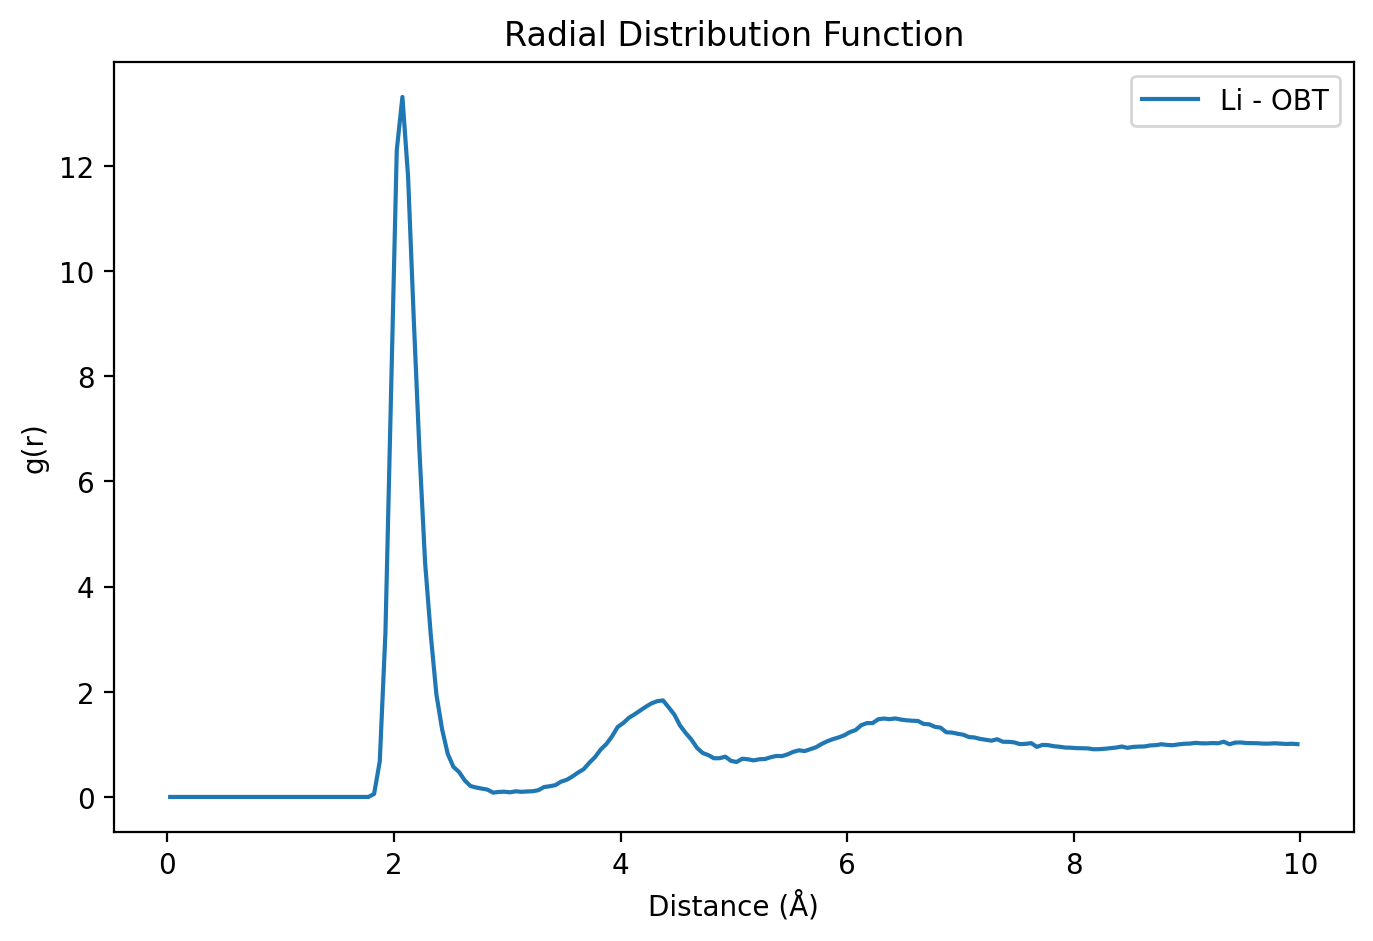

In [7]:

#  RDF between Li and the TFSI oxygen (OBT)
r, g_r = my_system.get_rdf("Li", "OBT", r_range=(0.0, 10.0), step=1000)

n_atoms = len(my_system.universe.select_atoms("all")) # total # of atoms
volume = (my_system.box_size * 1e-10) ** 3 #Å^3
print(n_atoms)
print(volume)
print(f"density = {n_atoms/volume}")

plt.figure(figsize=(8, 5))
plt.plot(r, g_r, label="Li - OBT")
#plt.plot(r, cn, label=" cn: Li - OBT")
plt.xlabel("Distance (Å)")
plt.ylabel("g(r)")
plt.legend()
plt.title("Radial Distribution Function")
plt.show()



Calculating RDF between resname Li (200 atoms) and all (2400 atoms)...
1st Solvation Shell Radius: 0.88 Å
1st Solvation Shell Coordination Number: 0.37


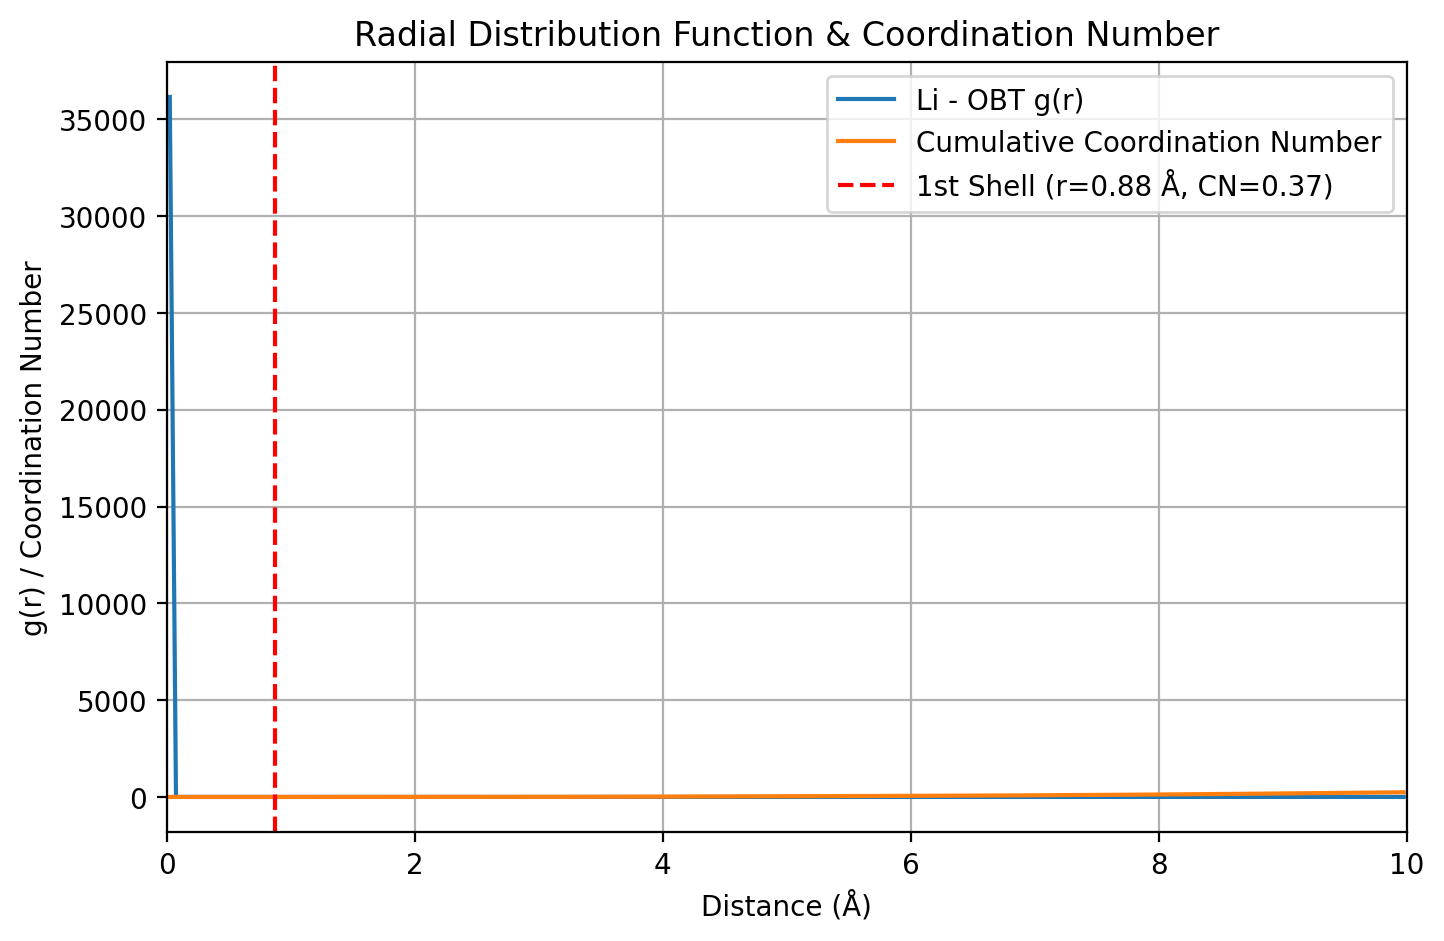

In [8]:

target_atom = 'all'

r, g_r = my_system.get_rdf("Li", target_atom, r_range=(0.0, 10.0), step=100)

# number density
mda_target_sel = my_system._build_selection_string(target_atom)
n_atoms = len(my_system.universe.select_atoms(mda_target_sel)) # total # of atoms

volume = my_system.box_size ** 3
rho = n_atoms / volume 

cn = 4 * np.pi * rho * intg.cumulative_trapezoid(g_r * (r**2), r, initial=0)
first_peak_idx = np.argmax(g_r)

# first minima after peak to integrate to
# invert g_r to find minima using find_peaks
minima, _ = find_peaks(-g_r[first_peak_idx:])
first_min_idx = first_peak_idx + minima[0]

shell_radius = r[first_min_idx]
shell_cn = cn[first_min_idx]

print(f"1st Solvation Shell Radius: {shell_radius:.2f} Å")
print(f"1st Solvation Shell Coordination Number: {shell_cn:.2f}")

# plotting
plt.figure(figsize=(8, 5))
plt.plot(r, g_r, label="Li - OBT g(r)", color='tab:blue')
plt.plot(r, cn, label="Cumulative Coordination Number", color='tab:orange')

# draw line at integration limit
plt.axvline(x=shell_radius, color='red', linestyle='--', 
            label=f'1st Shell (r={shell_radius:.2f} Å, CN={shell_cn:.2f})')
plt.xlabel("Distance (Å)")
plt.ylabel("g(r) / Coordination Number")
plt.legend()
plt.title("Radial Distribution Function & Coordination Number")
plt.xlim(0, 10)
plt.grid(True)
plt.show()

1st Solvation Shell Radius: 2.68 Å
1st Solvation Shell Coordination Number: 4.92


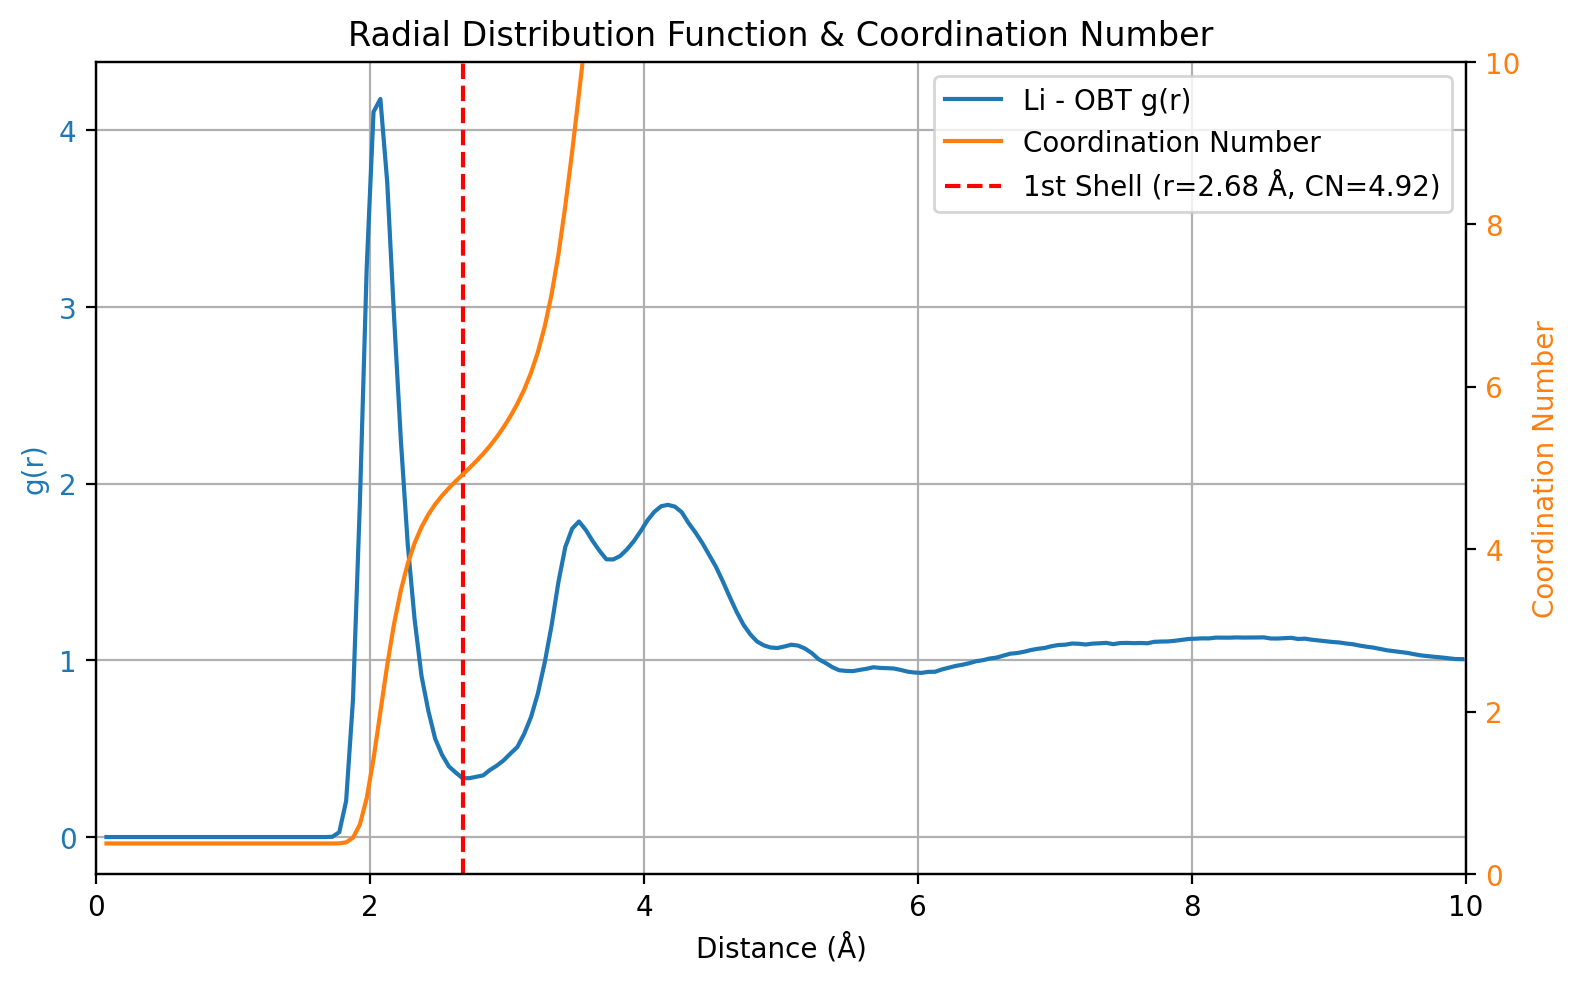

In [9]:
# 1. Apply the mask FIRST
mask = r < 10
gr_masked = g_r[mask][1:]
cn_masked = cn[mask][1:]
r_masked = r[mask][1:]

first_peak_idx = np.argmax(gr_masked) # run fro mfirst peak otherwise it would have jsut seen the r=0 as the first peaks
minima, _ = find_peaks(-gr_masked[first_peak_idx:])
first_min_idx = first_peak_idx + minima[0]
shell_radius = r_masked[first_min_idx]
shell_cn = cn_masked[first_min_idx]

print(f"1st Solvation Shell Radius: {shell_radius:.2f} Å")
print(f"1st Solvation Shell Coordination Number: {shell_cn:.2f}")

fig, ax1 = plt.subplots(figsize=(8, 5))
color1 = 'tab:blue'
ax1.set_xlabel("Distance (Å)")
ax1.set_ylabel("g(r)", color=color1)
line1 = ax1.plot(r_masked, gr_masked, label="Li - OBT g(r)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlim(0, 10)
ax1.grid(True)

ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel("Coordination Number", color=color2)
line2 = ax2.plot(r_masked, cn_masked, label="Coordination Number", color=color2)
ax2.set_ylim((0,10))
ax2.tick_params(axis='y', labelcolor=color2)


line3 = ax1.axvline(x=shell_radius, color='red', linestyle='--', 
                    label=f'1st Shell (r={shell_radius:.2f} Å, CN={shell_cn:.2f})')


lines = line1 + line2 + [line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title("Radial Distribution Function & Coordination Number")
fig.tight_layout()
plt.show()

Calculating COM MSD for resname PF6 (100 molecules) over 4000 frames...


/home/felix/anaconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt
100%|██████████| 100/100 [00:00<00:00, 1513.48it/s]


Calculating Atom-averaged MSD for resname PF6 (700 atoms)...


100%|██████████| 700/700 [00:00<00:00, 1496.45it/s]


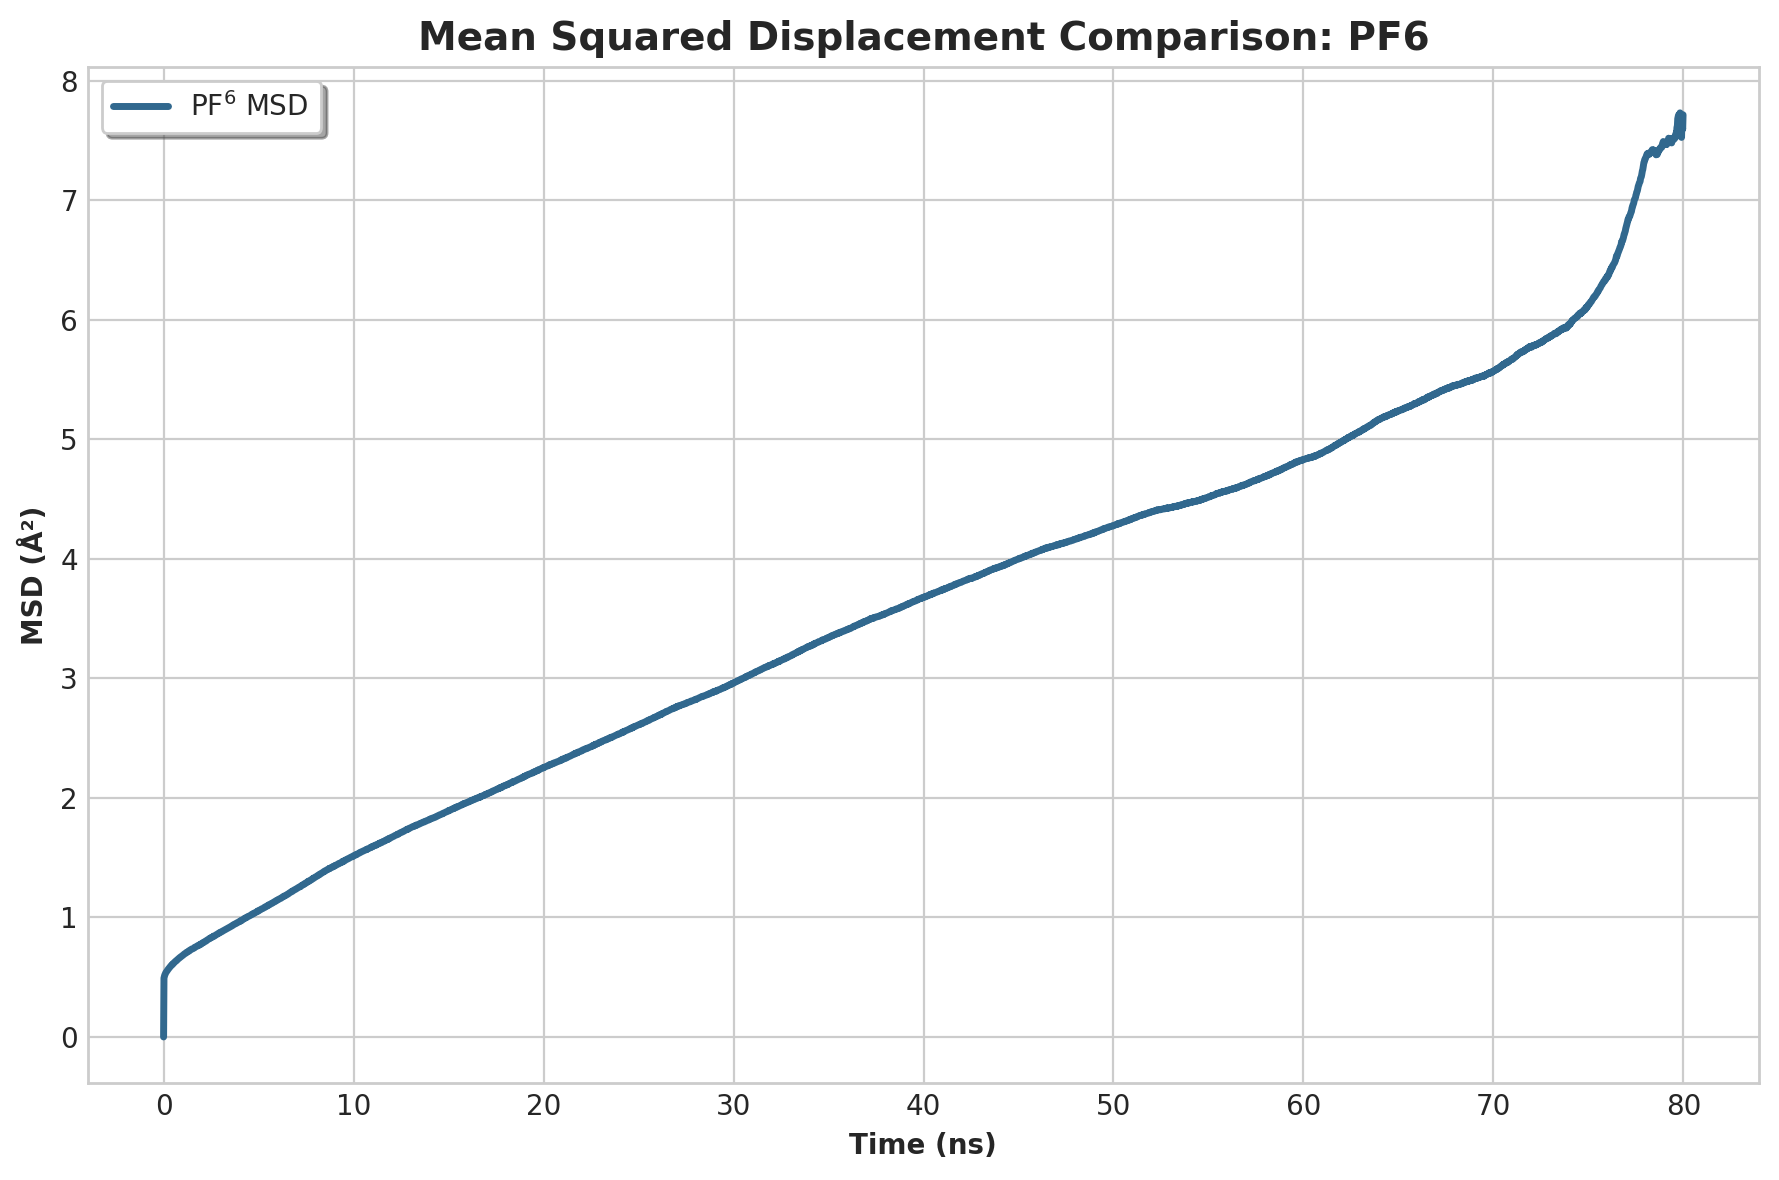

In [10]:


plt.style.use('seaborn-v0_8-whitegrid')
colors = sns.color_palette('viridis', 2)

# Get MSD for PF6 (COM vs Atom-averaged)
step = 20
time_ns, msd_pf6_com = my_system.get_msd('PF6', step=step, com=True)
_, msd_pf6_atom     = my_system.get_msd('PF6', step=step, com=False)

plt.figure(figsize=(9, 6), dpi=100)


plt.plot(time_ns, msd_pf6_com, label='PF$^6$ MSD ', 
         color=colors[0], linewidth=2.5, zorder=2)

plt.xlabel('Time (ns)', fontweight='bold')
plt.ylabel('MSD (Å²)', fontweight='bold')
plt.title('Mean Squared Displacement Comparison: PF6', fontsize=14, fontweight='bold')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()


/home/felix/anaconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


Calculating COM MSD for resname PF6 (100 molecules) over 4000 frames...


100%|██████████| 100/100 [00:00<00:00, 1576.42it/s]


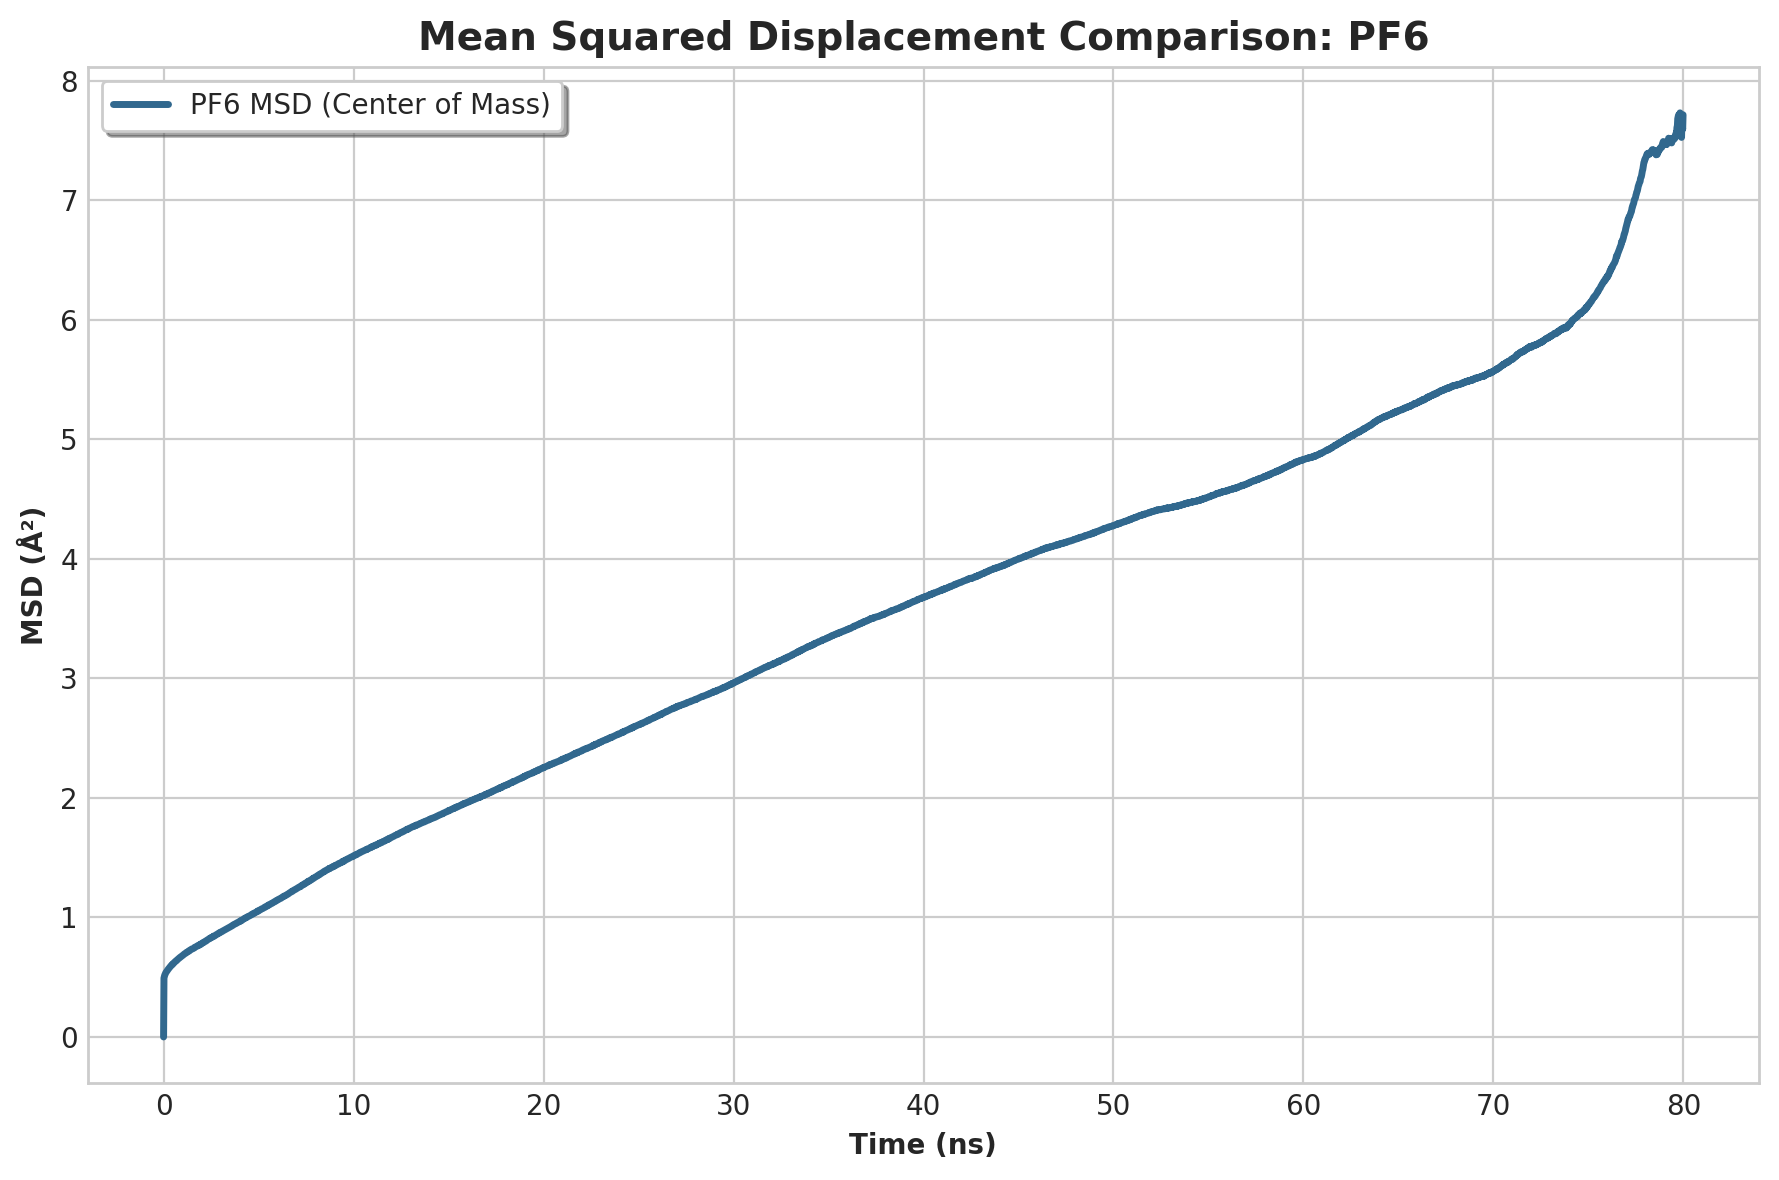

In [11]:


plt.style.use('seaborn-v0_8-whitegrid')
colors = sns.color_palette('viridis', 2)

# Get MSD for PF6 (COM vs Atom-averaged)
step = 20
time_ns, msd_pf6_com = my_system.get_msd('PF6', step=step, com=True)

plt.figure(figsize=(9, 6), dpi=100)

# Plot both with distinct styles
plt.plot(time_ns, msd_pf6_com, label='PF6 MSD (Center of Mass)', 
         color=colors[0], linewidth=2.5, zorder=2)

plt.xlabel('Time (ns)', fontweight='bold')
plt.ylabel('MSD (Å²)', fontweight='bold')
plt.title('Mean Squared Displacement Comparison: PF6', fontsize=14, fontweight='bold')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()
